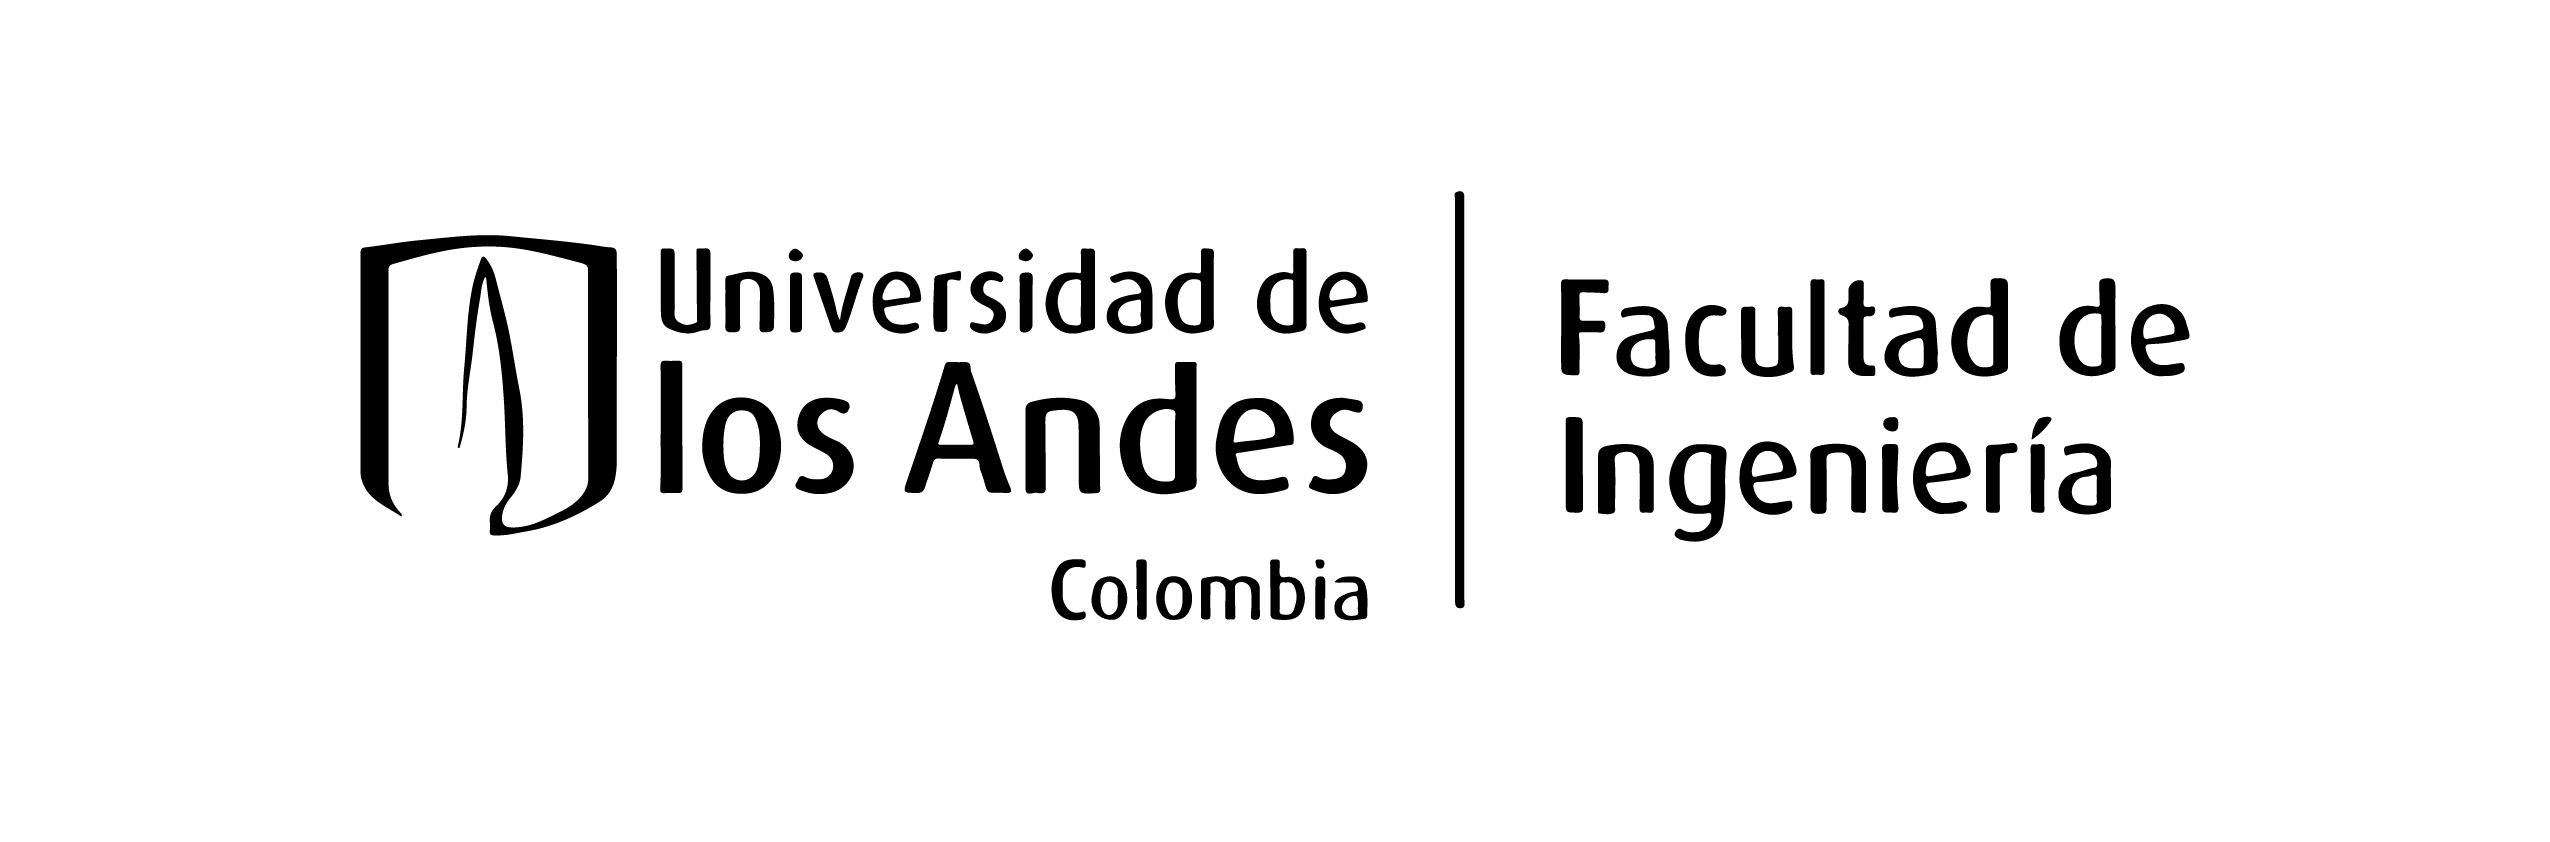

<font color='black' align="center"><h1> </h1></font>

<font color='black'><h1 align="center">IMEC 3260 - Introducción al Vuelo</h1></font>

<font color='black'><h1 align="center">Profesor: Andrés González Mancera </h1></font>

<font color='black'><h1 align="center">Taller 4

<font color='black'><h1 align="center">Carlos Ernesto Upegui - 202213004<br></h1></font>

</h1></font>


<br>

<br>

<font color='black'><center>Abril 17 2026<br>Primer Semestre 2026 <br>Bogotá DC – Colombia </center><br></font>



In [ ]:
from pathlib import Path
import unicodedata, re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, OrderedDict, Counter
from pathlib import Path
from collections import defaultdict, Counter
import re, pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib import patheffects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import re, unicodedata
import math
import os, shutil
from scipy.integrate import simpson
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import warnings
from IPython.display import display, HTML
from sympy import symbols, sqrt, pi, Eq, solve, Rational, latex, oo, diff, simplify, latex
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import brentq
from IPython.display import display, HTML, Math
from scipy.interpolate import interp1d

<strong><font color='black'><h1><left> Problema 1:</left><h1></strong>
</font>

<strong><font color='black'><u><h2><left>Solución - Ejercicio 1:</left><h2></font></strong>

<em><font color='black'><left>Definimos las variables</left></font></em>



In [ ]:
rho, V, W_sym, S_sym, C_D0, K_sym = symbols('rho V W S C_{D0} K', positive=True)
C_L = symbols('C_L', positive=True)
h_sym = symbols('h', positive=True)

valores_conocidos = {
    S_sym: 3.24,        # m²
    W_sym: 1850,        # N
    C_D0: 0.0065,
    K_sym: 1/(pi*0.88*16),
}

S_val = 3.24
AR_val = 16
e_val = 0.88
W_val = 1850
CD0_val = 0.0065
K_val = 1 / (np.pi * e_val * AR_val)
TA_SL_val = 400
CL_max_val = 1.35
g_val = 9.80665

rho_0_val = 1.225
T_0_val = 288.15
P_0_val = 101325
R_air = 287.058

valores_encontrados = {}

print(f'K = {K_val:.5f}')

K = 0.02261


<em><font color='black'><left>Definimos las ecuaciones</left></font></em>



In [ ]:
def atm_ISA(h):
    a_lapse = -0.0065
    T = T_0_val + a_lapse * h
    exp_p = g_val / (R_air * abs(a_lapse))
    P = P_0_val * (T / T_0_val) ** exp_p
    rho = P / (R_air * T)
    return T, rho

def rho_at(h):
    _, rho = atm_ISA(h)
    return rho

def TA_func(h):
    return TA_SL_val * (rho_at(h) / rho_0_val)

def V_stall_func(h):
    return np.sqrt(2 * W_val / (rho_at(h) * S_val * CL_max_val))

def CL_func(V, rho):
    return 2 * W_val / (rho * V**2 * S_val)

def CDi_func(CL):
    return K_val * CL**2

def CD_func(CL):
    return CD0_val + K_val * CL**2

def LD_func(CL):
    return CL / CD_func(CL)

def TR_func(V, rho):
    CL = CL_func(V, rho)
    CD = CD_func(CL)
    return 0.5 * rho * V**2 * S_val * CD

def PR_func(V, rho):
    return TR_func(V, rho) * V

def PA_func(V, h):
    return TA_func(h) * V

def V_from_CL(CL, h):
    return np.sqrt(2 * W_val / (rho_at(h) * S_val * CL))


<em><strong><font color='black'><left>Parte (a): mínimo de TR contra velocidad</left></font></strong></em>

<font color='black'><left>
En vuelo nivelado:
<br><br>
L = W
<br><br>
CL = 2W / (rho * V^2 * S)
<br><br>
CD = CD0 + K * CL^2
<br><br>
TR = D = W * (CD / CL) = W * (CD0 / CL + K * CL)
<br><br>
Para encontrar el mínimo de TR respecto a CL:
<br>
d(TR)/d(CL) = 0
<br><br>
Eso lleva a:
<br>
CD0 = CDi
<br><br>
Con esa condición se obtiene CL* y luego V*.
</left></font>


<em><font color='black'><left>Resolvemos las ecuaciones</left></font></em>



In [ ]:
CL_star_val = np.sqrt(CD0_val / K_val)
LD_max_val = CL_star_val / (2 * CD0_val)
TR_min_val = W_val / LD_max_val

V_star_SL = V_from_CL(CL_star_val, 0.0)
V_star_8km = V_from_CL(CL_star_val, 8000.0)

valores_encontrados["CL*"] = f"{CL_star_val:.4f}"
valores_encontrados["(L/D)_max"] = f"{LD_max_val:.2f}"
valores_encontrados["TR_min"] = f"{TR_min_val:.2f} N"
valores_encontrados["V* (SL)"] = f"{V_star_SL:.2f} m/s"
valores_encontrados["V* (8 km)"] = f"{V_star_8km:.2f} m/s"

print("Resultados parte (a):")
for key in ["CL*", "(L/D)_max", "TR_min", "V* (SL)", "V* (8 km)"]:
    print(f"  {key} = {valores_encontrados[key]}")

rho_SL = rho_at(0.0)
rho_8 = rho_at(8000.0)

V_arr_SL = np.linspace(V_stall_func(0.0) * 1.001, 160.0, 4000)
TR_arr_SL = np.array([TR_func(v, rho_SL) for v in V_arr_SL])
idx_star_SL = np.argmin(TR_arr_SL)
V_star_num_SL = V_arr_SL[idx_star_SL]
CL_star_num_SL = CL_func(V_star_num_SL, rho_SL)
CDi_star_num_SL = CDi_func(CL_star_num_SL)

V_arr_8 = np.linspace(V_stall_func(8000.0) * 1.001, 220.0, 4000)
TR_arr_8 = np.array([TR_func(v, rho_8) for v in V_arr_8])
idx_star_8 = np.argmin(TR_arr_8)
V_star_num_8 = V_arr_8[idx_star_8]
CL_star_num_8 = CL_func(V_star_num_8, rho_8)
CDi_star_num_8 = CDi_func(CL_star_num_8)

print("Verificación numérica parte (a)")
print(f"  A nivel del mar: V* numérica = {V_star_num_SL:.2f} m/s")
print(f"  A nivel del mar: CDi(V*) = {CDi_star_num_SL:.6f}, CD0 = {CD0_val:.6f}")
print(f"  A 8 km: V* numérica = {V_star_num_8:.2f} m/s")
print(f"  A 8 km: CDi(V*) = {CDi_star_num_8:.6f}, CD0 = {CD0_val:.6f}")

Resultados parte (a):
  CL* = 0.5362
  (L/D)_max = 41.25
  TR_min = 44.85 N
  V* (SL) = 41.70 m/s
  V* (8 km) = 63.68 m/s
Verificación numérica parte (a)
  A nivel del mar: V* numérica = 41.68 m/s
  A nivel del mar: CDi(V*) = 0.006508, CD0 = 0.006500
  A 8 km: V* numérica = 63.69 m/s
  A 8 km: CDi(V*) = 0.006496, CD0 = 0.006500



<em><strong><font color='black'><left>Parte (b): mínimo de PR contra velocidad</left></font></strong></em>

<font color='black'><left>
Como PR = TR * V y V es proporcional a 1 / sqrt(CL), entonces:
<br><br>
PR es proporcional a:
<br>
CD0 / CL^(3/2) + K * CL^(1/2)
<br><br>
Al imponer d(PR)/d(CL) = 0 se obtiene:
<br><br>
CD0 = (1/3) * CDi
<br><br>
Esta condición ocurre a una velocidad menor que V* porque requiere un CL mayor,
y un CL mayor significa una velocidad menor para sostener el peso.
</left></font>


In [ ]:
CL_starstar_val = np.sqrt(3.0 * CD0_val / K_val)
V_starstar_SL = V_from_CL(CL_starstar_val, 0.0)
V_starstar_8km = V_from_CL(CL_starstar_val, 8000.0)

V_arr_SL_PR = np.linspace(V_stall_func(0.0) * 1.001, 160.0, 4000)
PR_arr_SL = np.array([PR_func(v, rho_SL) for v in V_arr_SL_PR])
idx_starstar_SL = np.argmin(PR_arr_SL)
V_starstar_num_SL = V_arr_SL_PR[idx_starstar_SL]
CL_starstar_num_SL = CL_func(V_starstar_num_SL, rho_SL)
CDi_starstar_num_SL = CDi_func(CL_starstar_num_SL)

V_arr_8_PR = np.linspace(V_stall_func(8000.0) * 1.001, 220.0, 4000)
PR_arr_8 = np.array([PR_func(v, rho_8) for v in V_arr_8_PR])
idx_starstar_8 = np.argmin(PR_arr_8)
V_starstar_num_8 = V_arr_8_PR[idx_starstar_8]
CL_starstar_num_8 = CL_func(V_starstar_num_8, rho_8)
CDi_starstar_num_8 = CDi_func(CL_starstar_num_8)

valores_encontrados["CL**"] = f"{CL_starstar_val:.4f}"
valores_encontrados["V** (SL)"] = f"{V_starstar_SL:.2f} m/s"
valores_encontrados["V** (8 km)"] = f"{V_starstar_8km:.2f} m/s"

print("Resultados parte (b):")
print(f"  CL** = {CL_starstar_val:.4f}")
print(f"  V** (SL) = {V_starstar_SL:.2f} m/s")
print(f"  V** (8 km) = {V_starstar_8km:.2f} m/s")
print()
print("Verificación numérica parte (b)")
print(f"  A nivel del mar: V** numérica = {V_starstar_num_SL:.2f} m/s")
print(f"  A nivel del mar: CDi(V**) = {CDi_starstar_num_SL:.6f}, 3*CD0 = {3*CD0_val:.6f}")
print(f"  A 8 km: V** numérica = {V_starstar_num_8:.2f} m/s")
print(f"  A 8 km: CDi(V**) = {CDi_starstar_num_8:.6f}, 3*CD0 = {3*CD0_val:.6f}")

Resultados parte (b):
  CL** = 0.9287
  V** (SL) = 31.68 m/s
  V** (8 km) = 48.39 m/s

Verificación numérica parte (b)
  A nivel del mar: V** numérica = 31.69 m/s
  A nivel del mar: CDi(V**) = 0.019488, 3*CD0 = 0.019500
  A 8 km: V** numérica = 48.40 m/s
  A 8 km: CDi(V**) = 0.019475, 3*CD0 = 0.019500



<em><strong><font color='black'><left>Parte (c): curvas TR, PR/V y PR a nivel del mar</left></font></strong></em>

<font color='black'><left>
Para turbofan:
<br><br>
TA(h) = TA_SL * rho(h) / rho0
<br><br>
PA = TA * V
<br><br>

</left></font>


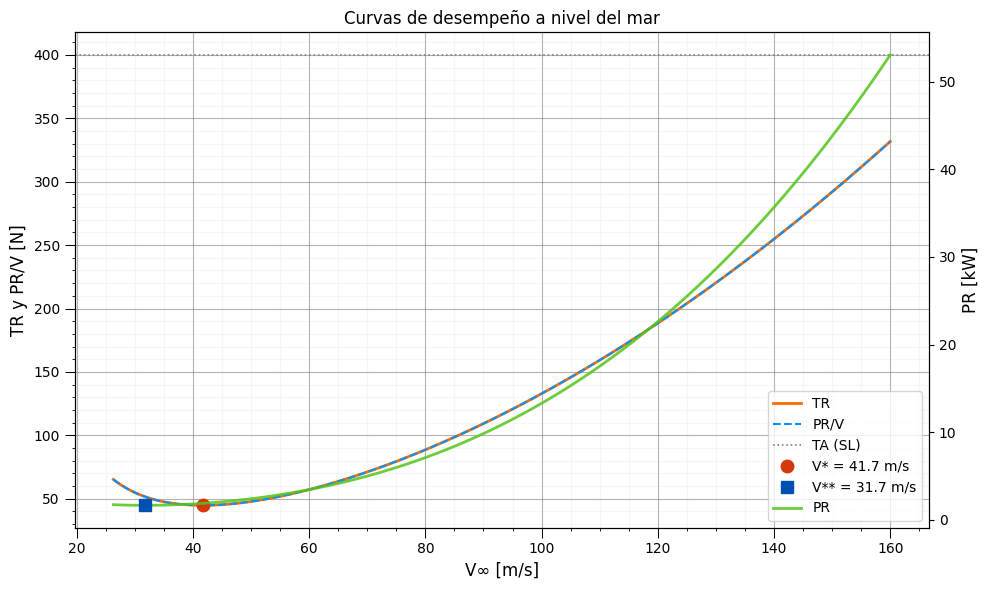

Chequeos numéricos de la figura:
  En V*: CDi / CD0 = 1.0012
  En V**: CDi / (3*CD0) = 0.9994
  PR/V coincide con TR a precisión numérica.


In [ ]:
V_plot = np.linspace(V_stall_func(0.0) * 1.001, 160.0, 4000)
TR_plot = np.array([TR_func(v, rho_SL) for v in V_plot])
PR_plot = np.array([PR_func(v, rho_SL) for v in V_plot])
TR_over_V_plot = PR_plot / V_plot

TR_star = TR_func(V_star_SL, rho_SL)
PR_starstar = PR_func(V_starstar_SL, rho_SL)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(V_plot, TR_plot, color='#ff6d01', lw=2, label='TR')
ax1.plot(V_plot, TR_over_V_plot, color='#0192ff', lw=1.5, ls='--', label='PR/V')
ax1.axhline(TA_func(0.0), color='gray', lw=1.2, ls=':', label='TA (SL)')

ax1.plot(V_star_SL, TR_star, 'o', color='#d4380d', ms=9, zorder=5,
         label=f'V* = {V_star_SL:.1f} m/s')
ax2.plot(V_starstar_SL, PR_starstar / 1000.0, 's', color='#0050b3', ms=8, zorder=5,
         label=f'V** = {V_starstar_SL:.1f} m/s')

ax2.plot(V_plot, PR_plot / 1000.0, color='#52c41a', lw=2, alpha=0.85, label='PR')

ax1.set_xlabel('V∞ [m/s]', fontsize=12)
ax1.set_ylabel('TR y PR/V [N]', fontsize=12)
ax2.set_ylabel('PR [kW]', fontsize=12)
ax1.set_title('Curvas de desempeño a nivel del mar', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='best')

ax1.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax1.grid(visible=True, which='major', color='grey', linestyle='-')
ax1.minorticks_on()
ax1.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

print("Chequeos numéricos de la figura:")
print(f"  En V*: CDi / CD0 = {CDi_star_num_SL / CD0_val:.4f}")
print(f"  En V**: CDi / (3*CD0) = {CDi_starstar_num_SL / (3*CD0_val):.4f}")
print("  PR/V coincide con TR.")


<em><strong><font color='black'><left>Parte (d): penalización de volar a 163 m/s</left></font></strong></em>

<font color='black'><left>
Se evalúa la condición de crucero a 8 km y se compara con el empuje mínimo:
<br><br>
TR_crucero / TR_min
<br><br>
También se calcula la fracción de arrastre parásito y de arrastre inducido.
</left></font>


In [ ]:
V_cr = 163.0
rho_cr = rho_at(8000.0)

CL_cr = CL_func(V_cr, rho_cr)
CDi_cr = CDi_func(CL_cr)
CD_cr = CD_func(CL_cr)
LD_cr = LD_func(CL_cr)
TR_cr = TR_func(V_cr, rho_cr)

ratio_TR = TR_cr / TR_min_val
frac_parasita = CD0_val / CD_cr
frac_inducida = CDi_cr / CD_cr

valores_encontrados["CL crucero (8 km)"] = f"{CL_cr:.4f}"
valores_encontrados["L/D crucero (8 km)"] = f"{LD_cr:.2f}"
valores_encontrados["TR crucero (8 km)"] = f"{TR_cr:.2f} N"
valores_encontrados["TR_crucero / TR_min"] = f"{ratio_TR:.2f}"
valores_encontrados["Fracción arrastre parásito"] = f"{100*frac_parasita:.2f} %"
valores_encontrados["Fracción arrastre inducido"] = f"{100*frac_inducida:.2f} %"

print("Resultados parte (d):")
for key in [
    "CL crucero (8 km)",
    "L/D crucero (8 km)",
    "TR crucero (8 km)",
    "TR_crucero / TR_min",
    "Fracción arrastre parásito",
    "Fracción arrastre inducido",
]:
    print(f"  {key} = {valores_encontrados[key]}")

Resultados parte (d):
  CL crucero (8 km) = 0.0818
  L/D crucero (8 km) = 12.30
  TR crucero (8 km) = 150.35 N
  TR_crucero / TR_min = 3.35
  Fracción arrastre parásito = 97.72 %
  Fracción arrastre inducido = 2.28 %



<em><strong><font color='black'><left>Parte (e): reflexión de diseño</left></font></strong></em>

<font color='black'><left>
1) Para reducir CD0 sin cambiar AR ni e, conviene mejorar la limpieza aerodinámica del ala:
mejor acabado superficial, menos rugosidad, un perfil más limpio o más laminar,
menor interferencia en uniones y detalles más pulidos.
<br><br>
2) Para aumentar V* sin modificar el peso, se puede reducir el área alar S.
Como V* depende de la raíz cuadrada de W dividido por rho, S y CL*,
una menor área obliga al dron a volar más rápido para generar la misma sustentación.
</left></font>



<em><font color='black'><left>Resumen final de resultados</left></font></em>


In [ ]:
print("Resumen final:")
for key, val in valores_encontrados.items():
    print(f"  {key} = {val}")

Resumen final:
  CL* = 0.5362
  (L/D)max = 41.25
  T_R,min = 44.85 N
  V* (SL) = 41.70 m/s
  V* (8 km) = 63.68 m/s
  (L/D)_max = 41.25
  TR_min = 44.85 N
  CL** = 0.9287
  V** (SL) = 31.68 m/s
  V** (8 km) = 48.39 m/s
  CL crucero (8 km) = 0.0818
  L/D crucero (8 km) = 12.30
  TR crucero (8 km) = 150.35 N
  TR_crucero / TR_min = 3.35
  Fracción arrastre parásito = 97.72 %
  Fracción arrastre inducido = 2.28 %


<strong><font color='black'><h1><left> Problema 2:</left><h1></strong>
</font>

<strong><font color='black'><u><h2><left>Solución - Ejercicio 2:</left><h2></font></strong>

<em><font color='black'><left>Definimos las variables</left></font></em>



In [ ]:
# Símbolos
rho, V, W_sym, S_sym, C_D0, K_sym, T_A_SL = symbols('rho V W S C_{D0} K T_{A_{SL}}', positive=True)
C_L, C_D, C_L_max_sym = symbols('C_L C_D C_{L_{max}}', positive=True)
h_sym, g_sym = symbols('h g', positive=True)

valores_conocidos = {
    S_sym: 3.24,        # m²
    W_sym: 1850,        # N
    C_D0: 0.0065,
    K_sym: 0.02261,
    T_A_SL: 400,        # N
    C_L_max_sym: 1.35,
    g_sym: 9.80665,     # m/s²
}

S_val = 3.24
AR_val = 16
e_val = 0.88
W_val = 1850
CD0_val = 0.0065
K_val = 1 / (np.pi * e_val * AR_val)
TA_SL_val = 400
CL_max_val = 1.35
g_val = 9.80665

rho_0_val = 1.225
T_0_val = 288.15
P_0_val = 101325
R_air = 287.058

CL_star_val = np.sqrt(CD0_val / K_val)
LD_max_val = CL_star_val / (2 * CD0_val)

valores_encontrados = {}

print(f'K = {K_val:.5f}')
print(f'CL* = {CL_star_val:.4f}')
print(f'(L/D)max = {LD_max_val:.2f}')

K = 0.02261
CL* = 0.5362
(L/D)max = 41.25


<em><font color='black'><left>Definimos las ecuaciones</left></font></em>



In [ ]:
def atm_ISA(h):
    a_lapse = -0.0065
    T = T_0_val + a_lapse * h
    exp_p = g_val / (R_air * abs(a_lapse))
    P = P_0_val * (T / T_0_val) ** exp_p
    rho = P / (R_air * T)
    return T, rho

def rho_at(h):
    _, rho = atm_ISA(h)
    return rho

def TA_func(h):
    return TA_SL_val * (rho_at(h) / rho_0_val)

def V_stall_func(h):
    return np.sqrt(2 * W_val / (rho_at(h) * S_val * CL_max_val))

def TR_func(V, rho):
    CL = 2 * W_val / (rho * V**2 * S_val)
    CD = CD0_val + K_val * CL**2
    return 0.5 * rho * V**2 * S_val * CD

def PR_func(V, rho):
    return TR_func(V, rho) * V

def RC_func(V, h):
    rho = rho_at(h)
    PA = TA_func(h) * V
    PR = PR_func(V, rho)
    return (PA - PR) / W_val


<em><strong><font color='black'><left>Parte (a): RC vs V∞ a nivel del mar — Identificar Vy y Vx</left></font></strong></em>



<font color='black'><left>
La tasa de ascenso se obtiene del balance de potencia:<br><br>
RC = (PA − PR) / W = (TA·V − TR·V) / W<br><br>
Para turbofan: TA = TA,SL · ρ/ρ₀ = cte con V a altitud fija.<br>
Vy: velocidad a la que RC es máxima.<br>
Vx: velocidad a la que el ángulo de ascenso θ = arcsin(RC/V) es máximo.
</left></font>


<em><font color='black'><left>Resolvemos las ecuaciones</left></font></em>



  V_stall (SL) = 26.28 m/s
  Vy (SL) = 102.16 m/s
  RC_max (SL) = 14.45 m/s
  θ_Vy = 8.13°
  Vx (SL) = 41.70 m/s
  RC en Vx = 8.01 m/s
  θ_Vx = 11.07°


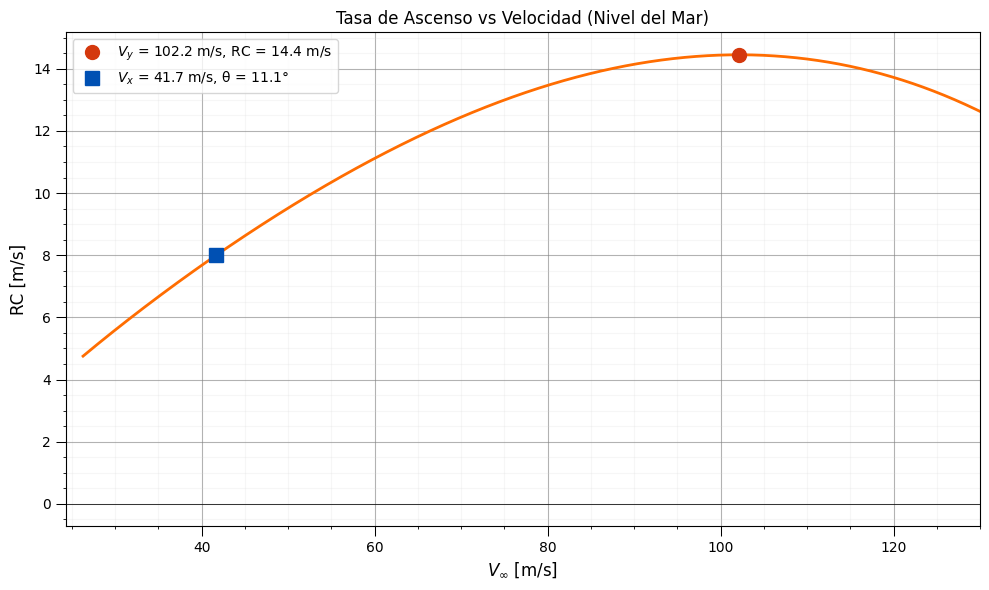

In [ ]:
h_sl = 0
Vs_SL = V_stall_func(h_sl)

V_arr = np.linspace(Vs_SL, 130, 3000)
RC_arr = np.array([RC_func(v, h_sl) for v in V_arr])

idx_Vy = np.argmax(RC_arr)
Vy_SL = V_arr[idx_Vy]
RC_max_SL = RC_arr[idx_Vy]
theta_Vy = np.degrees(np.arcsin(RC_max_SL / Vy_SL))

sin_theta = RC_arr / V_arr
idx_Vx = np.argmax(sin_theta)
Vx_SL = V_arr[idx_Vx]
RC_Vx_SL = RC_arr[idx_Vx]
theta_Vx = np.degrees(np.arcsin(sin_theta[idx_Vx]))

valores_encontrados['V_stall (SL)'] = f'{Vs_SL:.2f} m/s'
valores_encontrados['Vy (SL)'] = f'{Vy_SL:.2f} m/s'
valores_encontrados['RC_max (SL)'] = f'{RC_max_SL:.2f} m/s'
valores_encontrados['θ_Vy'] = f'{theta_Vy:.2f}°'
valores_encontrados['Vx (SL)'] = f'{Vx_SL:.2f} m/s'
valores_encontrados['RC en Vx'] = f'{RC_Vx_SL:.2f} m/s'
valores_encontrados['θ_Vx'] = f'{theta_Vx:.2f}°'

for key, val in valores_encontrados.items():
    print(f'  {key} = {val}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(V_arr, RC_arr, color='#ff6d01', lw=2)
ax.plot(Vy_SL, RC_max_SL, 'o', color='#d4380d', ms=10, zorder=5,
        label=f'$V_y$ = {Vy_SL:.1f} m/s, RC = {RC_max_SL:.1f} m/s')
ax.plot(Vx_SL, RC_Vx_SL, 's', color='#0050b3', ms=10, zorder=5,
        label=f'$V_x$ = {Vx_SL:.1f} m/s, θ = {theta_Vx:.1f}°')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel(r'$V_\infty$ [m/s]', fontsize=12)
ax.set_ylabel('RC [m/s]', fontsize=12)
ax.set_title('Tasa de Ascenso vs Velocidad (Nivel del Mar)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([Vs_SL - 2, 130])
ax.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax.grid(visible=True, which='major', color='grey', linestyle='-')
ax.minorticks_on()
ax.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()


<em><strong><font color='black'><left>Parte (b): Hodógrafo de ascenso a nivel del mar</left></font></strong></em>


<font color='black'><left>

Vy es el punto más alto de la curva.<br>
Vx corresponde al máximo ángulo θ. Para identificarlo se traza la tangente
desde el origen: si toca un punto interior, Vx está determinado por el empuje;
si la tangente pasa por el extremo izquierdo, Vx está limitado por la pérdida (stall).
</left></font>


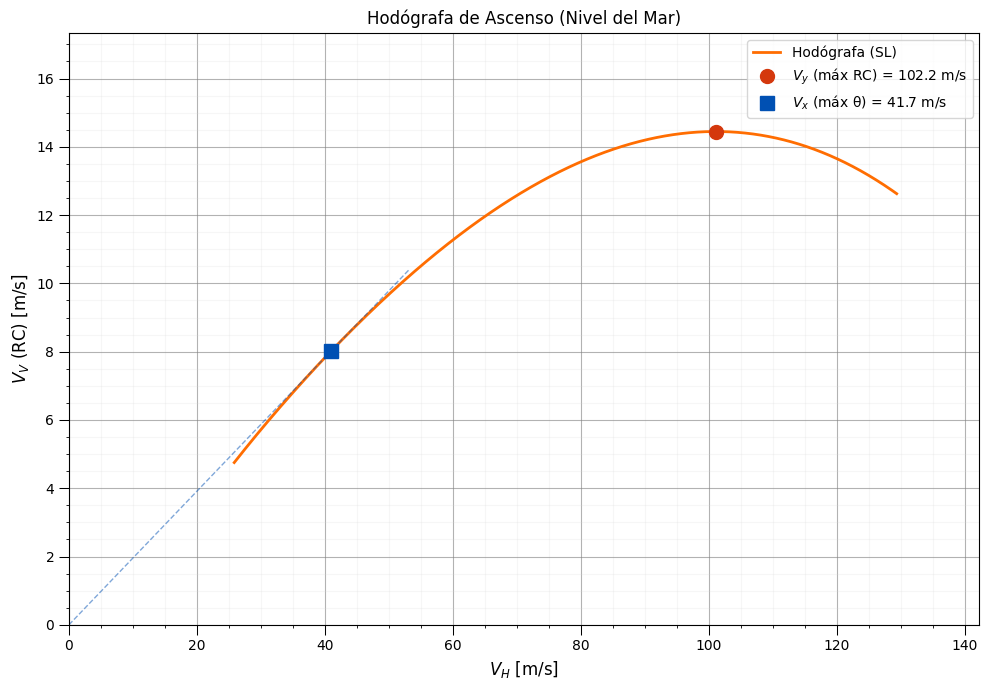

In [ ]:
VV_sl = RC_arr.copy()
theta_rad = np.arcsin(np.clip(VV_sl / V_arr, -1, 1))
VH_sl = V_arr * np.cos(theta_rad)

mask_pos = VV_sl > 0
VH_plot = VH_sl[mask_pos]
VV_plot = VV_sl[mask_pos]

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(VH_plot, VV_plot, color='#ff6d01', lw=2, label='Hodógrafa (SL)')

VV_Vy = RC_max_SL
VH_Vy = Vy_SL * np.cos(np.arcsin(RC_max_SL / Vy_SL))
ax.plot(VH_Vy, VV_Vy, 'o', color='#d4380d', ms=10, zorder=5,
        label=f'$V_y$ (máx RC) = {Vy_SL:.1f} m/s')

VV_Vx = RC_Vx_SL
VH_Vx = Vx_SL * np.cos(np.arcsin(RC_Vx_SL / Vx_SL))
ax.plot(VH_Vx, VV_Vx, 's', color='#0050b3', ms=10, zorder=5,
        label=f'$V_x$ (máx θ) = {Vx_SL:.1f} m/s')

ax.plot([0, VH_Vx * 1.3], [0, VV_Vx / VH_Vx * VH_Vx * 1.3],
        '--', color='#0050b3', lw=1, alpha=0.5)

ax.set_xlabel(r'$V_H$ [m/s]', fontsize=12)
ax.set_ylabel(r'$V_V$ (RC) [m/s]', fontsize=12)
ax.set_title('Hodógrafa de Ascenso (Nivel del Mar)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0, max(VH_plot) * 1.1])
ax.set_ylim([0, max(VV_plot) * 1.2])
ax.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax.grid(visible=True, which='major', color='grey', linestyle='-')
ax.minorticks_on()
ax.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

<font color='black'><left>

→ Vx es un <strong>punto interior</strong> de la hodógrafa, determinado por el empuje disponible
(la tangente desde el origen toca la curva en un punto interior, no en el extremo izquierdo).
El máximo ángulo de ascenso NO está limitado por la pérdida para este dron a nivel del mar.
</left></font>

<em><font color='black'><left>Parte (c): Hodógrafas a SL, 5 km y 8 km</left></font></em>

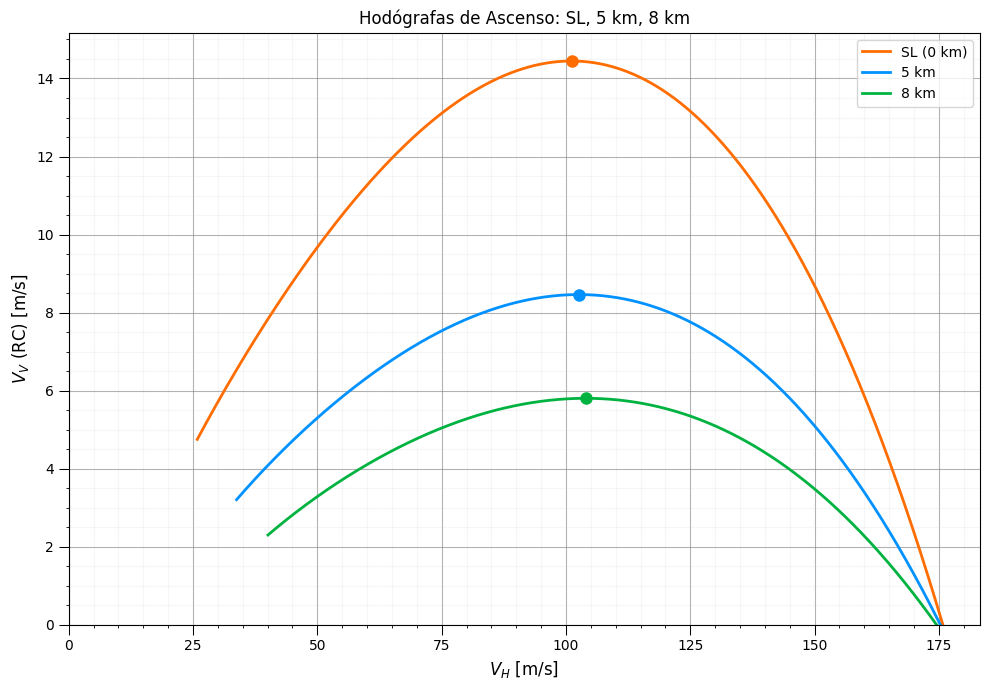

In [ ]:
altitudes = [0, 5000, 8000]
labels_h = ['SL (0 km)', '5 km', '8 km']
colors_h = ['#ff6d01', '#0192ff', '#00b341']

fig, ax = plt.subplots(figsize=(10, 7))

for h_val, lab, col in zip(altitudes, labels_h, colors_h):
    Vs_h = V_stall_func(h_val)
    V_h = np.linspace(Vs_h, 200, 3000)
    RC_h = np.array([RC_func(v, h_val) for v in V_h])

    mask = RC_h > 0
    if not np.any(mask):
        continue

    V_pos = V_h[mask]
    RC_pos = RC_h[mask]
    theta_h = np.arcsin(np.clip(RC_pos / V_pos, -1, 1))
    VH_h = V_pos * np.cos(theta_h)
    VV_h = RC_pos

    ax.plot(VH_h, VV_h, color=col, lw=2, label=lab)

    idx_vy = np.argmax(RC_pos)
    VV_vy = RC_pos[idx_vy]
    VH_vy = V_pos[idx_vy] * np.cos(np.arcsin(VV_vy / V_pos[idx_vy]))
    ax.plot(VH_vy, VV_vy, 'o', color=col, ms=8, zorder=5)

ax.set_xlabel(r'$V_H$ [m/s]', fontsize=12)
ax.set_ylabel(r'$V_V$ (RC) [m/s]', fontsize=12)
ax.set_title('Hodógrafas de Ascenso: SL, 5 km, 8 km', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0, None])
ax.set_ylim([0, None])
ax.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax.grid(visible=True, which='major', color='grey', linestyle='-')
ax.minorticks_on()
ax.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

<font color='black'><left>
A medida que aumenta la altitud:<br>
La hodógrafa se vuelve más pequeña por un menor exceso de potencia porque TA baja con ρ, mientras que PR no disminuye proporcionalmente. También, se desplaza a la derecha V_stall aumenta porque ρ baja (se necesita más velocidad para generar sustentación).<br>
El punto más alto (Vy) desciende porque la RC máxima disminuye progresivamente. Eventualmente la hodógrafa colapsa a un solo punto en el techo absoluto, donde RC = 0 y no queda exceso de potencia.<br>
Esto implica que las posibilidades de ascenso se reducen con la altitud hasta que el dron alcanza su techo operativo.
</left></font>

<em><font color='black'><left>Parte (d): Vx(h) y Vy(h) hasta el techo absoluto</left></font></em>

In [ ]:
h_range = np.linspace(0, 20000, 500)
Vx_h = []
Vy_h = []
RCmax_h = []

for h_val in h_range:
    Vs_h = V_stall_func(h_val)
    V_h = np.linspace(Vs_h, 300, 3000)
    RC_h = np.array([RC_func(v, h_val) for v in V_h])

    rc_max = np.max(RC_h)
    RCmax_h.append(rc_max)

    if rc_max <= 0:
        Vx_h.append(np.nan)
        Vy_h.append(np.nan)
        continue

    idx_vy = np.argmax(RC_h)
    Vy_h.append(V_h[idx_vy])

    mask = RC_h > 0
    sin_th = RC_h[mask] / V_h[mask]
    idx_vx = np.argmax(sin_th)
    Vx_h.append(V_h[mask][idx_vx])

Vx_h = np.array(Vx_h)
Vy_h = np.array(Vy_h)
RCmax_h = np.array(RCmax_h)

mask_pos_rc = RCmax_h > 0
rc_interp = interp1d(h_range[mask_pos_rc], RCmax_h[mask_pos_rc],
                     kind='linear', fill_value='extrapolate')

try:
    h_techo = brentq(rc_interp, h_range[mask_pos_rc][-10], h_range[mask_pos_rc][-1] + 2000)
except:
    idx_t = np.where(~mask_pos_rc)[0][0]
    h_techo = h_range[idx_t]

mask_valid = ~np.isnan(Vx_h) & ~np.isnan(Vy_h)
V_convergencia = Vy_h[mask_valid][-1]

valores_encontrados['Techo absoluto'] = f'{h_techo:.0f} m ({h_techo/1000:.2f} km)'
valores_encontrados['V convergencia'] = f'{V_convergencia:.1f} m/s'

print(f'  Techo absoluto = {h_techo:.0f} m ({h_techo/1000:.2f} km)')
print(f'  V convergencia (Vx→Vy) = {V_convergencia:.1f} m/s')

  Techo absoluto = 17820 m (17.82 km)
  V convergencia (Vx→Vy) = 124.4 m/s


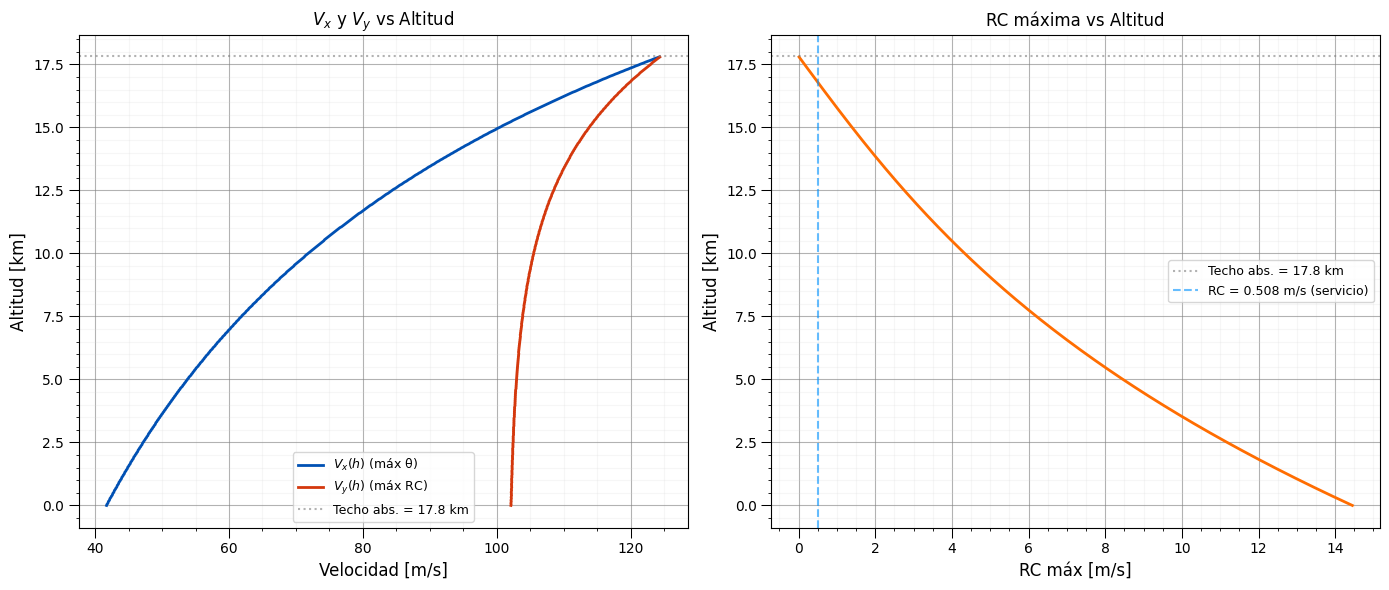

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(Vx_h[mask_valid], h_range[mask_valid] / 1000, color='#0050b3', lw=2, label=r'$V_x(h)$ (máx θ)')
ax1.plot(Vy_h[mask_valid], h_range[mask_valid] / 1000, color='#d4380d', lw=2, label=r'$V_y(h)$ (máx RC)')
ax1.axhline(h_techo / 1000, color='gray', ls=':', alpha=0.6, label=f'Techo abs. = {h_techo/1000:.1f} km')
ax1.set_xlabel('Velocidad [m/s]', fontsize=12)
ax1.set_ylabel('Altitud [km]', fontsize=12)
ax1.set_title(r'$V_x$ y $V_y$ vs Altitud', fontsize=12)
ax1.legend(fontsize=9)
ax1.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax1.grid(visible=True, which='major', color='grey', linestyle='-')
ax1.minorticks_on()
ax1.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)

ax2.plot(RCmax_h[mask_valid], h_range[mask_valid] / 1000, color='#ff6d01', lw=2)
ax2.axhline(h_techo / 1000, color='gray', ls=':', alpha=0.6, label=f'Techo abs. = {h_techo/1000:.1f} km')
ax2.axvline(0.508, color='#0192ff', ls='--', alpha=0.6, label='RC = 0.508 m/s (servicio)')
ax2.set_xlabel('RC máx [m/s]', fontsize=12)
ax2.set_ylabel('Altitud [km]', fontsize=12)
ax2.set_title('RC máxima vs Altitud', fontsize=12)
ax2.legend(fontsize=9)
ax2.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax2.grid(visible=True, which='major', color='grey', linestyle='-')
ax2.minorticks_on()
ax2.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
rc_fine = interp1d(h_range[mask_pos_rc], RCmax_h[mask_pos_rc], kind='linear')
try:
    h_servicio = brentq(lambda h: rc_fine(h) - 0.508, 0, h_techo - 100)
except:
    h_servicio = None

h_climb = np.linspace(0, 8000, 2000)
RC_climb = []

for h_val in h_climb:
    Vs_h = V_stall_func(h_val)
    V_h = np.linspace(Vs_h, 300, 2000)
    RC_h = np.array([RC_func(v, h_val) for v in V_h])
    RC_climb.append(np.max(RC_h))

RC_climb = np.array(RC_climb)
mask_rc_pos = RC_climb > 0.01
dt_dh = 1.0 / RC_climb[mask_rc_pos]
h_int = h_climb[mask_rc_pos]
t_climb = cumulative_trapezoid(dt_dh, h_int, initial=0)
t_8km = t_climb[-1]

valores_encontrados['Techo de servicio'] = f'{h_servicio:.0f} m ({h_servicio/1000:.2f} km)' if h_servicio else 'N/A'
valores_encontrados['Tiempo ascenso 8 km'] = f'{t_8km:.1f} s ({t_8km/60:.2f} min)'

print(f'  Techo absoluto      = {h_techo:.0f} m ({h_techo/1000:.2f} km)')
print(f'  Techo de servicio   = {h_servicio:.0f} m ({h_servicio/1000:.2f} km)')
print(f'  Tiempo ascenso 8 km = {t_8km:.1f} s ({t_8km/60:.2f} min)')

  Techo absoluto      = 17820 m (17.82 km)
  Techo de servicio   = 16776 m (16.78 km)
  Tiempo ascenso 8 km = 882.6 s (14.71 min)


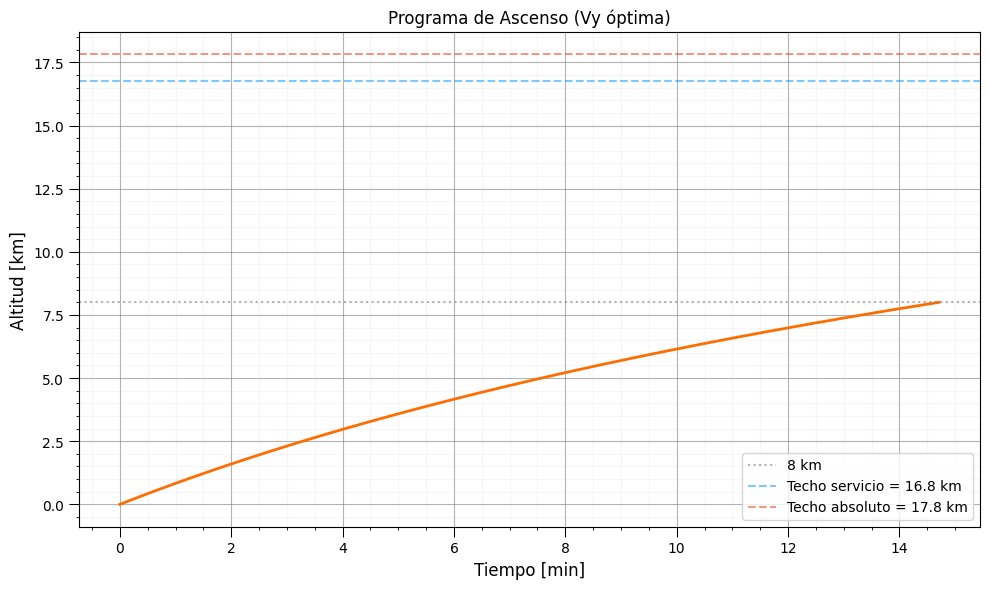

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_climb / 60, h_int / 1000, color='#ff6d01', lw=2)
ax.axhline(8, color='gray', ls=':', alpha=0.6, label='8 km')
if h_servicio is not None:
    ax.axhline(h_servicio / 1000, color='#0192ff', ls='--', alpha=0.5,
               label=f'Techo servicio = {h_servicio/1000:.1f} km')
ax.axhline(h_techo / 1000, color='#d4380d', ls='--', alpha=0.5,
           label=f'Techo absoluto = {h_techo/1000:.1f} km')
ax.set_xlabel('Tiempo [min]', fontsize=12)
ax.set_ylabel('Altitud [km]', fontsize=12)
ax.set_title('Programa de Ascenso (Vy óptima)', fontsize=12)
ax.legend(fontsize=10)
ax.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax.grid(visible=True, which='major', color='grey', linestyle='-')
ax.minorticks_on()
ax.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
display(HTML(f"""
<font color='black'><left>
<strong>Resultados:</strong><br>
<ul>
<li>Techo absoluto: {h_techo:.0f} m ({h_techo/1000:.2f} km) — altitud donde RC = 0.<br>
<li>echo de servicio: {h_servicio:.0f} m ({h_servicio/1000:.2f} km) — altitud donde RC = 0.508 m/s (100 ft/min).<br>
<li>Tiempo de ascenso a 8 km: {t_8km:.1f} s = {t_8km/60:.2f} min, obtenido por integración numérica
de t = ∫dh/RC_max(h) usando la regla del trapecio.</ul><br>
El programa de ascenso muestra una pendiente que disminuye con la altitud, lo que muestra
la reducción progresiva de RC_max conforme el empuje disponible cae con la densidad.
</left></font>
"""))

<strong><font color='black'><h1><left> Problema 3:</left><h1></strong>
</font>

<strong><font color='black'><u><h2><left>Solución - Ejercicio 3:</left><h2></font></strong>

<em><font color='black'><left>Definimos las variables</left></font></em>



In [ ]:
S_val = 3.24
AR_val = 16
e_val = 0.88
W_val = 1850.0
CD0_val = 0.0065
K_val = 1 / (np.pi * e_val * AR_val)
CL_max_val = 1.35
g_val = 9.80665

rho_0_val = 1.225
T_0_val = 288.15
P_0_val = 101325.0
R_air = 287.058

h_glide_val = 8000.0
zona_A_val = 310e3
zona_B_val = 290e3
V_headwind_val = 15.0

valores_conocidos = {
    "S": f"{S_val} m^2",
    "AR": AR_val,
    "e": e_val,
    "W": f"{W_val} N",
    "CD0": CD0_val,
    "K": round(K_val, 5),
    "CL_max": CL_max_val,
    "Altitud de falla": f"{h_glide_val:.0f} m",
    "Zona A": f"{zona_A_val/1000:.0f} km",
    "Zona B": f"{zona_B_val/1000:.0f} km",
    "Viento en contra": f"{V_headwind_val:.0f} m/s",
}

valores_encontrados = {}

print("Valores conocidos:")
for key, val in valores_conocidos.items():
    print(f"  {key} = {val}")

Valores conocidos:
  S = 3.24 m^2
  AR = 16
  e = 0.88
  W = 1850.0 N
  CD0 = 0.0065
  K = 0.02261
  CL_max = 1.35
  Altitud de falla = 8000 m
  Zona A = 310 km
  Zona B = 290 km
  Viento en contra = 15 m/s


<em><font color='black'><left>Definimos las ecuaciones </left></font></em>

In [ ]:
def atm_ISA(h):
    a_lapse = -0.0065
    T = T_0_val + a_lapse * h
    exp_p = g_val / (R_air * abs(a_lapse))
    P = P_0_val * (T / T_0_val) ** exp_p
    rho = P / (R_air * T)
    return T, rho

def rho_at(h):
    _, rho = atm_ISA(h)
    return rho

def V_stall_func(h):
    return np.sqrt(2 * W_val / (rho_at(h) * S_val * CL_max_val))

def CL_func(V, rho):
    return 2 * W_val / (rho * V**2 * S_val)

def CDi_func(CL):
    return K_val * CL**2

def CD_func(CL):
    return CD0_val + K_val * CL**2

def LD_func(CL):
    return CL / CD_func(CL)

def TR_func(V, rho):
    CL = CL_func(V, rho)
    CD = CD_func(CL)
    return 0.5 * rho * V**2 * S_val * CD

def PR_func(V, rho):
    return TR_func(V, rho) * V

def V_from_CL(CL, h):
    return np.sqrt(2 * W_val / (rho_at(h) * S_val * CL))

def gamma_glide_from_V(V, h):
    rho = rho_at(h)
    D = TR_func(V, rho)
    sin_gamma = -D / W_val
    sin_gamma = np.clip(sin_gamma, -1.0, 1.0)
    return np.arcsin(sin_gamma)

def VV_glide_func(V, h):
    gamma = gamma_glide_from_V(V, h)
    return V * np.sin(gamma)

def VH_glide_func(V, h):
    gamma = gamma_glide_from_V(V, h)
    return V * np.cos(gamma)

def sink_rate_func(V, h):
    return -VV_glide_func(V, h)

def ground_range_from_height(V, h, V_wind=0.0):
    VH = VH_glide_func(V, h)
    VV = VV_glide_func(V, h)
    VH_ground = VH - V_wind
    if VH_ground <= 0:
        return 0.0
    return h * VH_ground / abs(VV)

<em><strong><font color='black'><left>Parte (a): mínimo ángulo de planeo y alcance máximo</left></font></strong></em>

<font color='black'><left>
En planeo estacionario:
<br><br>
L = W * cos(theta)
<br><br>
D = W * sin(theta)
<br><br>
Por tanto:
<br><br>
tan(theta) = D / L = CD / CL = 1 / (L/D)
<br><br>
El mínimo ángulo de planeo ocurre cuando L/D es máximo.
Para una polar parabólica, eso pasa cuando:
<br><br>
CD0 = CDi
<br><br>
Con esa condición se obtiene CL de mejor planeo y luego la velocidad correspondiente.
</left></font>

In [ ]:
CL_star_val = np.sqrt(CD0_val / K_val)
LD_max_val = CL_star_val / (2 * CD0_val)
theta_min_rad = np.arctan(1.0 / LD_max_val)
theta_min_deg = np.degrees(theta_min_rad)

V_best_glide = V_from_CL(CL_star_val, h_glide_val)
R_max_glide = h_glide_val / np.tan(theta_min_rad)

alcanza_A = "Sí" if R_max_glide >= zona_A_val else "No"
alcanza_B = "Sí" if R_max_glide >= zona_B_val else "No"

valores_encontrados["CL mejor planeo"] = f"{CL_star_val:.4f}"
valores_encontrados["(L/D)_max"] = f"{LD_max_val:.2f}"
valores_encontrados["theta_min"] = f"{theta_min_deg:.2f} deg"
valores_encontrados["V mejor planeo (8 km)"] = f"{V_best_glide:.2f} m/s"
valores_encontrados["Alcance máximo"] = f"{R_max_glide/1000:.2f} km"
valores_encontrados["¿Alcanza Zona A?"] = alcanza_A
valores_encontrados["¿Alcanza Zona B?"] = alcanza_B

print("Resultados parte (a):")
for key in [
    "CL mejor planeo",
    "(L/D)_max",
    "theta_min",
    "V mejor planeo (8 km)",
    "Alcance máximo",
    "¿Alcanza Zona A?",
    "¿Alcanza Zona B?",
]:
    print(f"  {key} = {valores_encontrados[key]}")

Resultados parte (a):
  CL mejor planeo = 0.5362
  (L/D)_max = 41.25
  theta_min = 1.39 deg
  V mejor planeo (8 km) = 63.68 m/s
  Alcance máximo = 329.97 km
  ¿Alcanza Zona A? = Sí
  ¿Alcanza Zona B? = Sí


<em><strong><font color='black'><left>Parte (b): hundimiento mínimo y hodógrafo de planeo</left></font></strong></em>

<font color='black'><left>
La magnitud del hundimiento es:
<br><br>
ws = -VV
<br><br>
En planeo, D = W * sin(theta), así que:
<br><br>
ws = V * D / W = PR / W
<br><br>
Entonces el hundimiento mínimo ocurre donde PR es mínimo.
Para la polar parabólica, eso sucede cuando:
<br><br>
CD0 = (1/3) * CDi
<br><br>
Con esa condición se obtiene la velocidad de mínimo hundimiento.
</left></font>

In [ ]:
CL_starstar_val = np.sqrt(3.0 * CD0_val / K_val)
V_min_sink = V_from_CL(CL_starstar_val, h_glide_val)
ws_min_val = sink_rate_func(V_min_sink, h_glide_val)
t_max_val = h_glide_val / ws_min_val

valores_encontrados["CL mínimo hundimiento"] = f"{CL_starstar_val:.4f}"
valores_encontrados["V mínimo hundimiento (8 km)"] = f"{V_min_sink:.2f} m/s"
valores_encontrados["ws_min"] = f"{ws_min_val:.3f} m/s"
valores_encontrados["Tiempo máximo en el aire"] = f"{t_max_val/3600:.3f} h ({t_max_val/60:.1f} min)"

print("Resultados parte (b):")
for key in [
    "CL mínimo hundimiento",
    "V mínimo hundimiento (8 km)",
    "ws_min",
    "Tiempo máximo en el aire",
]:
    print(f"  {key} = {valores_encontrados[key]}")

Resultados parte (b):
  CL mínimo hundimiento = 0.9287
  V mínimo hundimiento (8 km) = 48.39 m/s
  ws_min = 1.355 m/s
  Tiempo máximo en el aire = 1.640 h (98.4 min)


<em><font color='black'><left>Construimos el hodógrafo de planeo a 8 km y marcamos los dos puntos especiales</left></font></em>

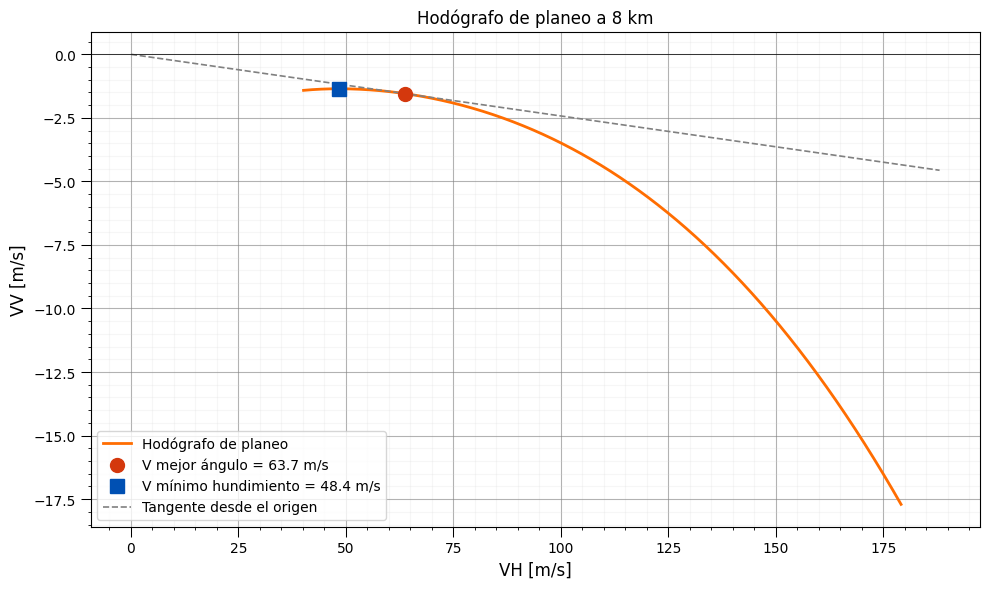

Puntos especiales del hodógrafo:
  Mejor ángulo: VH = 63.66 m/s, VV = -1.544 m/s
  Mínimo hundimiento: VH = 48.37 m/s, VV = -1.355 m/s


In [ ]:
rho_8km = rho_at(h_glide_val)
Vs_8km = V_stall_func(h_glide_val)
V_arr = np.linspace(Vs_8km * 1.001, 180.0, 4000)

VV_arr = np.array([VV_glide_func(v, h_glide_val) for v in V_arr])
VH_arr = np.array([VH_glide_func(v, h_glide_val) for v in V_arr])

VH_best = VH_glide_func(V_best_glide, h_glide_val)
VV_best = VV_glide_func(V_best_glide, h_glide_val)

VH_sink = VH_glide_func(V_min_sink, h_glide_val)
VV_sink = VV_glide_func(V_min_sink, h_glide_val)

m_tan = VV_best / VH_best
VH_line = np.linspace(0.0, np.max(VH_arr) * 1.05, 300)
VV_line = m_tan * VH_line

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(VH_arr, VV_arr, color='#ff6d01', lw=2, label='Hodógrafo de planeo')
ax.plot(VH_best, VV_best, 'o', color='#d4380d', ms=10, zorder=5,
        label=f'V mejor ángulo = {V_best_glide:.1f} m/s')
ax.plot(VH_sink, VV_sink, 's', color='#0050b3', ms=10, zorder=5,
        label=f'V mínimo hundimiento = {V_min_sink:.1f} m/s')
ax.plot(VH_line, VV_line, '--', color='gray', lw=1.2, label='Tangente desde el origen')
ax.axhline(0.0, color='black', lw=0.5)

ax.set_xlabel('VH [m/s]', fontsize=12)
ax.set_ylabel('VV [m/s]', fontsize=12)
ax.set_title('Hodógrafo de planeo a 8 km', fontsize=12)
ax.legend(fontsize=10)

ax.tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
ax.grid(visible=True, which='major', color='grey', linestyle='-')
ax.minorticks_on()
ax.grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

print("Puntos especiales del hodógrafo:")
print(f"  Mejor ángulo: VH = {VH_best:.2f} m/s, VV = {VV_best:.3f} m/s")
print(f"  Mínimo hundimiento: VH = {VH_sink:.2f} m/s, VV = {VV_sink:.3f} m/s")

<em><strong><font color='black'><left>Parte (c): decisión de vuelo con viento en contra de 15 m/s</left></font></strong></em>

<font color='black'><left>
La aerodinámica del planeo no cambia. Lo único que cambia es la velocidad horizontal sobre el suelo:
<br><br>
VH_suelo = VH - V_viento
<br><br>
Entonces el alcance sobre el suelo es:
<br><br>
R_suelo = h * VH_suelo / abs(VV)
<br><br>
Evaluamos ese alcance usando la velocidad de mejor ángulo.
</left></font>

In [ ]:
R_headwind = ground_range_from_height(V_best_glide, h_glide_val, V_wind=V_headwind_val)
alcanza_A_head = "Sí" if R_headwind >= zona_A_val else "No"
alcanza_B_head = "Sí" if R_headwind >= zona_B_val else "No"

valores_encontrados["Alcance con viento en contra"] = f"{R_headwind/1000:.2f} km"
valores_encontrados["¿Alcanza Zona A con viento?"] = alcanza_A_head
valores_encontrados["¿Alcanza Zona B con viento?"] = alcanza_B_head

print("Resultados parte (c):")
print(f"  VH en aire = {VH_best:.2f} m/s")
print(f"  VH sobre el suelo = {VH_best - V_headwind_val:.2f} m/s")
print(f"  Alcance con viento en contra = {R_headwind/1000:.2f} km")
print(f"  ¿Alcanza Zona A con viento? = {alcanza_A_head}")
print(f"  ¿Alcanza Zona B con viento? = {alcanza_B_head}")

Resultados parte (c):
  VH en aire = 63.66 m/s
  VH sobre el suelo = 48.66 m/s
  Alcance con viento en contra = 252.15 km
  ¿Alcanza Zona A con viento? = No
  ¿Alcanza Zona B con viento? = No


<em><strong><font color='black'><left>Parte (d): efecto del peso</left></font></strong></em>

<font color='black'><left>
El ángulo de planeo viene dado por:
<br><br>
tan(theta) = D / L = CD / CL
<br><br>
Esa expresión depende sólo de la polar, así que el ángulo de planeo mínimo no depende del peso.
<br><br>
Lo que sí cambia con el peso es la escala de velocidades:
<br><br>
V es proporcional a sqrt(W)
<br><br>
Por eso, si el dron pesa más, debe planear más rápido.
Además, la tasa de hundimiento mínima también aumenta con sqrt(W),
así que el tiempo máximo en el aire disminuye.
</left></font>

In [ ]:
print("Conclusión parte (d):")
print("  El ángulo mínimo de planeo no depende del peso.")
print("  El alcance máximo ideal desde una misma altura no cambia con el peso.")
print("  Sí cambian las velocidades características del planeo.")
print("  También aumenta la tasa de hundimiento mínima cuando el peso aumenta.")
print("  Por eso, un dron más pesado permanece menos tiempo en el aire durante el planeo.")

Conclusión parte (d):
  El ángulo mínimo de planeo no depende del peso.
  El alcance máximo ideal desde una misma altura no cambia con el peso.
  Sí cambian las velocidades características del planeo.
  También aumenta la tasa de hundimiento mínima cuando el peso aumenta.
  Por eso, un dron más pesado permanece menos tiempo en el aire durante el planeo.


<em><font color='black'><left>Resumen final de resultados</left></font></em>

In [ ]:
print("Resumen final:")
for key, val in valores_encontrados.items():
    print(f"  {key} = {val}")

Resumen final:
  CL mejor planeo = 0.5362
  (L/D)_max = 41.25
  theta_min = 1.39 deg
  V mejor planeo (8 km) = 63.68 m/s
  Alcance máximo = 329.97 km
  ¿Alcanza Zona A? = Sí
  ¿Alcanza Zona B? = Sí
  CL mínimo hundimiento = 0.9287
  V mínimo hundimiento (8 km) = 48.39 m/s
  ws_min = 1.355 m/s
  Tiempo máximo en el aire = 1.640 h (98.4 min)
  Alcance con viento en contra = 252.15 km
  ¿Alcanza Zona A con viento? = No
  ¿Alcanza Zona B con viento? = No


<strong><font color='black'><h1><left> Problema 4:</left><h1></strong>
</font>

<strong><font color='black'><u><h2><left>Solución - Ejercicio 4:</left><h2></font></strong>

<em><font color='black'><left>Definimos las variables</left></font></em>



In [ ]:
S_val = 3.24
AR_val = 16
e_val = 0.88
W_val = 1850.0
CD0_val = 0.0065
K_val = 1 / (np.pi * e_val * AR_val)
ct_val = 2.5e-4
fuel_fraction_val = 0.20

h_val = 8000.0
rho_8km_val = 0.4304
T_8km_val = 236.15
a_8km_val = 308.1

V_sprint_val = 163.0

W0_val = W_val
W1_val = W0_val * (1 - fuel_fraction_val)
ln_weight_ratio_val = np.log(W0_val / W1_val)

valores_conocidos = {
    "S": f"{S_val} m^2",
    "AR": AR_val,
    "e": e_val,
    "W0": f"{W0_val:.1f} N",
    "W1": f"{W1_val:.1f} N",
    "CD0": CD0_val,
    "K": round(K_val, 5),
    "ct": f"{ct_val:.2e} 1/s",
    "Fracción de combustible": f"{100*fuel_fraction_val:.0f} %",
    "Altitud de análisis": f"{h_val:.0f} m",
    "rho a 8 km": f"{rho_8km_val:.4f} kg/m^3",
    "T a 8 km": f"{T_8km_val:.2f} K",
    "a a 8 km": f"{a_8km_val:.1f} m/s",
}

valores_encontrados = {}

print("Valores conocidos:")
for key, val in valores_conocidos.items():
    print(f"  {key} = {val}")

Valores conocidos:
  S = 3.24 m^2
  AR = 16
  e = 0.88
  W0 = 1850.0 N
  W1 = 1480.0 N
  CD0 = 0.0065
  K = 0.02261
  ct = 2.50e-04 1/s
  Fracción de combustible = 20 %
  Altitud de análisis = 8000 m
  rho a 8 km = 0.4304 kg/m^3
  T a 8 km = 236.15 K
  a a 8 km = 308.1 m/s


<em><font color='black'><left>Definimos las ecuaciones </left></font></em>


In [ ]:
def CL_func(V, rho=rho_8km_val):
    return 2 * W_val / (rho * V**2 * S_val)

def CDi_func(CL):
    return K_val * CL**2

def CD_func(CL):
    return CD0_val + K_val * CL**2

def LD_func(CL):
    return CL / CD_func(CL)

def V_from_CL(CL, rho=rho_8km_val):
    return np.sqrt(2 * W_val / (rho * S_val * CL))

def range_breguet(V, LD):
    return (V / ct_val) * LD * ln_weight_ratio_val

def endurance_breguet(LD):
    return (1 / ct_val) * LD * ln_weight_ratio_val

def range_endurance_from_V(V):
    CL = CL_func(V)
    LD = LD_func(CL)
    R = range_breguet(V, LD)
    E = endurance_breguet(LD)
    return CL, LD, R, E

<em><strong><font color='black'><left>Parte (a): derivación de Breguet para turbina</left></font></strong></em>

<font color='black'><left>
En vuelo nivelado con turbina:
<br><br>
dW/dt = -ct * D
<br><br>
y como D = W / (L/D), entonces:
<br><br>
dW/dt = -ct * W / (L/D)
<br><br>
Para autonomía:
<br><br>
dt = -(1/ct) * (L/D) * dW / W
<br><br>
Al integrar desde W0 hasta W1:
<br><br>
E = (1/ct) * (L/D) * ln(W0 / W1)
<br><br>
Para alcance, como dx/dt = V:
<br><br>
dx = V * dt
<br><br>
Entonces:
<br><br>
R = (V/ct) * (L/D) * ln(W0 / W1)
<br><br>
La autonomía máxima ocurre donde L/D es máximo.
El alcance máximo ocurre donde V * (L/D) es máximo.
Como V aumenta cuando CL disminuye, el máximo alcance aparece a una velocidad mayor que la de máximo L/D.
El término que produce ese desplazamiento es precisamente V en la expresión de alcance.
</left></font>

In [ ]:
CL_endurance_val = np.sqrt(CD0_val / K_val)
CD_endurance_val = CD_func(CL_endurance_val)
LD_endurance_val = LD_func(CL_endurance_val)
V_endurance_val = V_from_CL(CL_endurance_val)

CL_range_val = np.sqrt(CD0_val / (3 * K_val))
CD_range_val = CD_func(CL_range_val)
LD_range_val = LD_func(CL_range_val)
V_range_val = V_from_CL(CL_range_val)

valores_encontrados["CL max autonomía"] = f"{CL_endurance_val:.4f}"
valores_encontrados["V max autonomía"] = f"{V_endurance_val:.2f} m/s"
valores_encontrados["L/D max autonomía"] = f"{LD_endurance_val:.2f}"

valores_encontrados["CL max alcance"] = f"{CL_range_val:.4f}"
valores_encontrados["V max alcance"] = f"{V_range_val:.2f} m/s"
valores_encontrados["L/D max alcance"] = f"{LD_range_val:.2f}"

print("Resultados parte (a):")
for key in [
    "CL max autonomía",
    "V max autonomía",
    "L/D max autonomía",
    "CL max alcance",
    "V max alcance",
    "L/D max alcance",
]:
    print(f"  {key} = {valores_encontrados[key]}")

print()
print("Condiciones óptimas encontradas:")
print("  Máxima autonomía turbina: CD0 = CDi")
print("  Máximo alcance turbina: CD0 = 3 * CDi")

Resultados parte (a):
  CL max autonomía = 0.5362
  V max autonomía = 70.34 m/s
  L/D max autonomía = 41.25
  CL max alcance = 0.3096
  V max alcance = 92.58 m/s
  L/D max alcance = 35.72

Condiciones óptimas encontradas:
  Máxima autonomía turbina: CD0 = CDi
  Máximo alcance turbina: CD0 = 3 * CDi


<em><strong><font color='black'><left>Parte (b): cálculo numérico de los perfiles de misión</left></font></strong></em>

<font color='black'><left>
Se calculan tres casos:
<br><br>
1) Perfil de máximo alcance Breguet
<br>
2) Perfil de máxima autonomía Breguet
<br>
3) Misión Sprint a 163 m/s y 8 km
</left></font>

In [ ]:
# Máxima autonomía
R_at_endurance_val = range_breguet(V_endurance_val, LD_endurance_val)
E_max_val = endurance_breguet(LD_endurance_val)

# Máximo alcance
R_max_val = range_breguet(V_range_val, LD_range_val)
E_at_range_val = endurance_breguet(LD_range_val)

# Sprint
CL_sprint_val, LD_sprint_val, R_sprint_val, E_sprint_val = range_endurance_from_V(V_sprint_val)

tabla_breguet = pd.DataFrame([
    {
        "Perfil de misión": "Máx alcance (Breguet)",
        "V (m/s)": round(V_range_val, 2),
        "CL": round(CL_range_val, 4),
        "L/D": round(LD_range_val, 2),
        "Alcance (km)": round(R_max_val / 1000, 2),
        "Autonomía (h)": round(E_at_range_val / 3600, 3),
    },
    {
        "Perfil de misión": "Máx autonomía (Breguet)",
        "V (m/s)": round(V_endurance_val, 2),
        "CL": round(CL_endurance_val, 4),
        "L/D": round(LD_endurance_val, 2),
        "Alcance (km)": round(R_at_endurance_val / 1000, 2),
        "Autonomía (h)": round(E_max_val / 3600, 3),
    },
    {
        "Perfil de misión": "Sprint (163 m/s, 8 km)",
        "V (m/s)": round(V_sprint_val, 2),
        "CL": round(CL_sprint_val, 4),
        "L/D": round(LD_sprint_val, 2),
        "Alcance (km)": round(R_sprint_val / 1000, 2),
        "Autonomía (h)": round(E_sprint_val / 3600, 3),
    },
])

print(tabla_breguet.to_string(index=False))

valores_encontrados["R_max"] = f"{R_max_val/1000:.2f} km"
valores_encontrados["E_max"] = f"{E_max_val/3600:.3f} h"
valores_encontrados["R_sprint"] = f"{R_sprint_val/1000:.2f} km"
valores_encontrados["E_sprint"] = f"{E_sprint_val/3600:.3f} h"

       Perfil de misión  V (m/s)     CL   L/D  Alcance (km)  Autonomía (h)
  Máx alcance (Breguet)    92.58 0.3096 35.72       2951.69          8.856
Máx autonomía (Breguet)    70.34 0.5362 41.25       2589.76         10.227
 Sprint (163 m/s, 8 km)   163.00 0.0999 14.85       2160.33          3.682


<em><strong><font color='black'><left>Parte (c): figura de mérito, alcance y autonomía como función de la velocidad</left></font></strong></em>


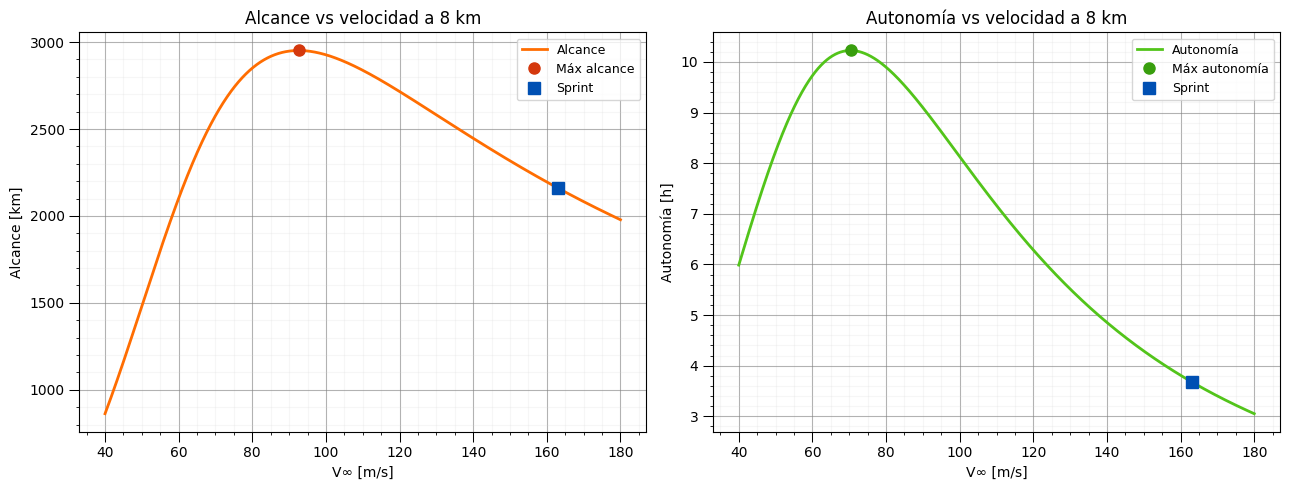

Resultados parte (c):
  Velocidad de máximo alcance = 92.58 m/s
  Alcance máximo = 2951.69 km
  Alcance Sprint = 2160.33 km
  Penalización en alcance = 26.81 %

  Velocidad de máxima autonomía = 70.34 m/s
  Autonomía máxima = 10.227 h
  Autonomía Sprint = 3.682 h
  Penalización en autonomía = 64.00 %


In [ ]:
V_min_plot = 40.0
V_max_plot = 180.0
V_arr = np.linspace(V_min_plot, V_max_plot, 4000)

CL_arr = CL_func(V_arr)
LD_arr = LD_func(CL_arr)
R_arr = range_breguet(V_arr, LD_arr)
E_arr = endurance_breguet(LD_arr)

idx_R = np.argmax(R_arr)
idx_E = np.argmax(E_arr)

V_R_num = V_arr[idx_R]
R_num = R_arr[idx_R]
V_E_num = V_arr[idx_E]
E_num = E_arr[idx_E]

penalty_range = (1 - R_sprint_val / R_max_val) * 100
penalty_endurance = (1 - E_sprint_val / E_max_val) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(V_arr, R_arr / 1000, color='#ff6d01', lw=2, label='Alcance')
axes[0].plot(V_range_val, R_max_val / 1000, 'o', color='#d4380d', ms=8, label='Máx alcance')
axes[0].plot(V_sprint_val, R_sprint_val / 1000, 's', color='#0050b3', ms=8, label='Sprint')
axes[0].set_xlabel('V∞ [m/s]')
axes[0].set_ylabel('Alcance [km]')
axes[0].set_title('Alcance vs velocidad a 8 km')
axes[0].legend(fontsize=9)
axes[0].tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
axes[0].grid(visible=True, which='major', color='grey', linestyle='-')
axes[0].minorticks_on()
axes[0].grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)

axes[1].plot(V_arr, E_arr / 3600, color='#52c41a', lw=2, label='Autonomía')
axes[1].plot(V_endurance_val, E_max_val / 3600, 'o', color='#389e0d', ms=8, label='Máx autonomía')
axes[1].plot(V_sprint_val, E_sprint_val / 3600, 's', color='#0050b3', ms=8, label='Sprint')
axes[1].set_xlabel('V∞ [m/s]')
axes[1].set_ylabel('Autonomía [h]')
axes[1].set_title('Autonomía vs velocidad a 8 km')
axes[1].legend(fontsize=9)
axes[1].tick_params(direction='out', length=7, width=0.75, grid_alpha=0.6)
axes[1].grid(visible=True, which='major', color='grey', linestyle='-')
axes[1].minorticks_on()
axes[1].grid(visible=True, which='minor', color='lightgrey', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

print("Resultados parte (c):")
print(f"  Velocidad de máximo alcance = {V_range_val:.2f} m/s")
print(f"  Alcance máximo = {R_max_val/1000:.2f} km")
print(f"  Alcance Sprint = {R_sprint_val/1000:.2f} km")
print(f"  Penalización en alcance = {penalty_range:.2f} %")
print()
print(f"  Velocidad de máxima autonomía = {V_endurance_val:.2f} m/s")
print(f"  Autonomía máxima = {E_max_val/3600:.3f} h")
print(f"  Autonomía Sprint = {E_sprint_val/3600:.3f} h")
print(f"  Penalización en autonomía = {penalty_endurance:.2f} %")

<em><strong><font color='black'><left>Parte (d): tabla de condiciones óptimas a 8 km</left></font></strong></em>

<font color='black'><left>
Se comparan las tres familias de condiciones óptimas:
<br><br>
1) CL / CD
<br>
2) CL^(3/2) / CD
<br>
3) CL^(1/2) / CD
<br><br>
La condición de máximo alcance turbina sale más rápida que la de máximo L/D,
por eso la igualdad correcta es:
<br><br>
CD0 = 3 * CDi
<br><br>
o, de manera equivalente:
<br><br>
CDi = CD0 / 3
</left></font>

In [ ]:
tabla_optimos = pd.DataFrame([
    {
        "Condición óptima": "Min TR / mejor planeo / max aut. turbina",
        "Se maximiza": "CL / CD",
        "Relación entre CD0 y CDi": "CD0 = CDi",
        "V a 8 km (m/s)": round(V_endurance_val, 2),
    },
    {
        "Condición óptima": "Min PR / min hundimiento / max aut. hélice",
        "Se maximiza": "CL^(3/2) / CD",
        "Relación entre CD0 y CDi": "CD0 = (1/3) * CDi",
        "V a 8 km (m/s)": round(V_from_CL(np.sqrt(3 * CD0_val / K_val)), 2),
    },
    {
        "Condición óptima": "Max alcance turbina",
        "Se maximiza": "CL^(1/2) / CD",
        "Relación entre CD0 y CDi": "CD0 = 3 * CDi",
        "V a 8 km (m/s)": round(V_range_val, 2),
    },
])

print(tabla_optimos.to_string(index=False))

                          Condición óptima   Se maximiza Relación entre CD0 y CDi  V a 8 km (m/s)
  Min TR / mejor planeo / max aut. turbina       CL / CD                CD0 = CDi           70.34
Min PR / min hundimiento / max aut. hélice CL^(3/2) / CD        CD0 = (1/3) * CDi           53.45
                       Max alcance turbina CL^(1/2) / CD            CD0 = 3 * CDi           92.58


<em><strong><font color='black'><left>Parte (e): síntesis final</left></font></strong></em><BR><font color='black'><br>
La misión Loiter es la que maximiza el tiempo sobre objetivo, porque vuela cerca de la condición de máxima autonomía, donde el dron obtiene el mayor tiempo de permanencia en el aire. En cambio, la mayor área de cobertura horizontal no la da Sprint sino la condición de máximo alcance, ya que esa velocidad maximiza la distancia recorrida por unidad de combustible. Aunque Sprint reduce mucho el tiempo de viaje, penaliza tanto el alcance como la autonomía frente a las condiciones óptimas. Para una misión mixta, recomendaría transitar cerca de la velocidad de máximo alcance para llegar lejos con buena eficiencia y, una vez en la zona de interés, reducir a la velocidad de máxima autonomía para maximizar el tiempo de vigilancia. Así se logra un compromiso táctico razonable entre cobertura, persistencia y consumo de combustible.</font >

<em><font color='black'><left>Resumen final de resultados</left></font></em>

In [ ]:
print("Resumen final:")
for key, val in valores_encontrados.items():
    print(f"  {key} = {val}")

Resumen final:
  CL max autonomía = 0.5362
  V max autonomía = 70.34 m/s
  L/D max autonomía = 41.25
  CL max alcance = 0.3096
  V max alcance = 92.58 m/s
  L/D max alcance = 35.72
  R_max = 2951.69 km
  E_max = 10.227 h
  R_sprint = 2160.33 km
  E_sprint = 3.682 h



>>> apt-get update -qq
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


>>> pip -q install nbconvert

>>> apt-get install -y -qq chromium
E: Package 'chromium' has no installation candidate


>>> apt-get install -y -qq chromium-browser
Preconfiguring packages ...
(Reading database ... 
(Reading database ... 5%
(Reading database ... 10%
(Reading database ... 15%
(Reading database ... 20%
(Reading database ... 25%
(Reading database ... 30%
(Reading database ... 35%
(Reading database ... 40%
(Reading database ... 45%
(Reading database ... 50%
(Reading database ... 55%
(Reading database ... 60%
(Reading database ... 65%
(Reading database ... 70%
(Reading database ... 75%
(Reading database ... 80%
(Reading database ... 85%
(Reading database ... 90%
(Reading database ... 95%
(Reading database ... 100%
(Reading database ... 118194 files and directories

RuntimeError: Falló el comando:
jupyter nbconvert --to html "/content/ejercicio_4_alcance_autonomia_sin_latex.ipynb"